Dataset: E-Commerce Shipping Data
Guiding Question: What factors (warehouse block, mode of shipment, product weight, discount offered) most accurately predict whether a shipment will arrive on time?

In [79]:
import pandas as pd
df = pd.read_csv("Train.csv")
df.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   10999 non-null  int64 
 1   Warehouse_block      10999 non-null  object
 2   Mode_of_Shipment     10999 non-null  object
 3   Customer_care_calls  10999 non-null  int64 
 4   Customer_rating      10999 non-null  int64 
 5   Cost_of_the_Product  10999 non-null  int64 
 6   Prior_purchases      10999 non-null  int64 
 7   Product_importance   10999 non-null  object
 8   Gender               10999 non-null  object
 9   Discount_offered     10999 non-null  int64 
 10  Weight_in_gms        10999 non-null  int64 
 11  Reached.on.Time_Y.N  10999 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 1.0+ MB


In [81]:
df.describe()

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,10999.00000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000
mean,5500.00000,4.054459,2.990545,210.196836,3.567597,13.373216,3634.016729,0.596691
std,3175.28214,1.141490,1.413603,48.063272,1.522860,16.205527,1635.377251,0.490584
min,1.00000,2.000000,1.000000,96.000000,2.000000,1.000000,1001.000000,0.000000
25%,2750.50000,3.000000,2.000000,169.000000,3.000000,4.000000,1839.500000,0.000000
50%,5500.00000,4.000000,3.000000,214.000000,3.000000,7.000000,4149.000000,1.000000
75%,8249.50000,5.000000,4.000000,251.000000,4.000000,10.000000,5050.000000,1.000000
max,10999.00000,7.000000,5.000000,310.000000,10.000000,65.000000,7846.000000,1.000000


In [82]:
df.isnull().sum()

ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64

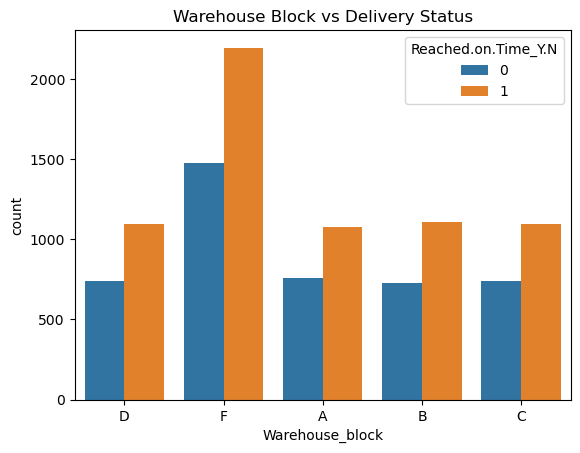

In [83]:
# Bar Charts / Count Plots
sns.countplot(
    x='Warehouse_block',
    hue='Reached.on.Time_Y.N',
    data=df
)
plt.title("Warehouse Block vs Delivery Status")
plt.show()
# sns.countplot(
#     x='Mode_of_Shipment',
#     hue='Reached.on.Time_Y.N',
#     data=df
# )
# plt.title("Shipment Mode vs Delivery Status")
# plt.show()

+Storytelling

Imagine an online store preparing thousands of orders every day. Products leave different warehouse blocks before beginning their journey to customers.

Warehouse F is the busiest hub, processing far more orders than the others. Despite handling the largest workload, most packages still arrive on time. Meanwhile, warehouses A, B, C, and D operate at a smaller scale but show a similar pattern of successful deliveries.

The story here is not about which warehouse is failing. Instead, it shows that as shipment volume increases, maintaining delivery performance becomes more challenging, yet the warehouses continue to deliver the majority of orders on schedule.

+Possible Actions for the Future:

Analyze the causes of delays: Investigate late shipments from each warehouse to identify common issues such as transportation, weather, or processing delays, and try to resolve the issues that are causing the delays.

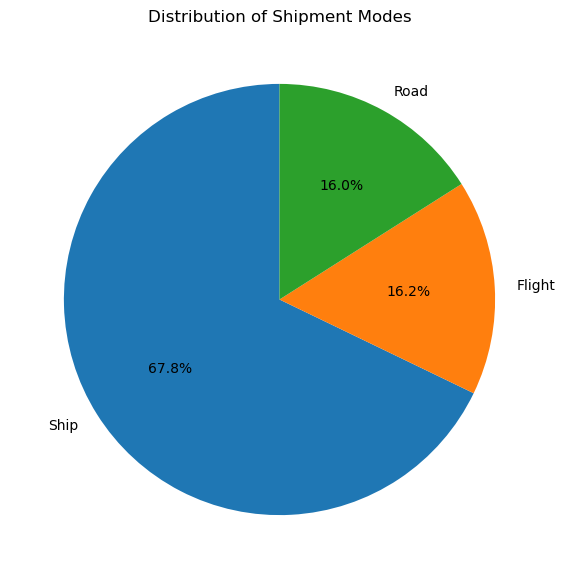

In [84]:
shipment_counts = df['Mode_of_Shipment'].value_counts()
plt.figure(figsize=(7,7))
plt.pie(
    shipment_counts,
    labels=shipment_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Distribution of Shipment Modes')
plt.show()

Storytelling

Imagine a busy e-commerce company delivering products across different regions. Every day, thousands of packages need to reach customers.

To handle this huge demand, the company relies heavily on ships, moving large quantities of products efficiently and economically. Meanwhile, flights are reserved for situations where speed is important, and road transport helps connect warehouses and customers locally.

The logistics strategy is like a balanced transportation network: ships carry the bulk of the workload, while flights and roads provide flexibility when needed.

Possible Actions for the Future:

Strengthen Road Transportation
Improve last-mile delivery operations to reduce delays between warehouses and customers.


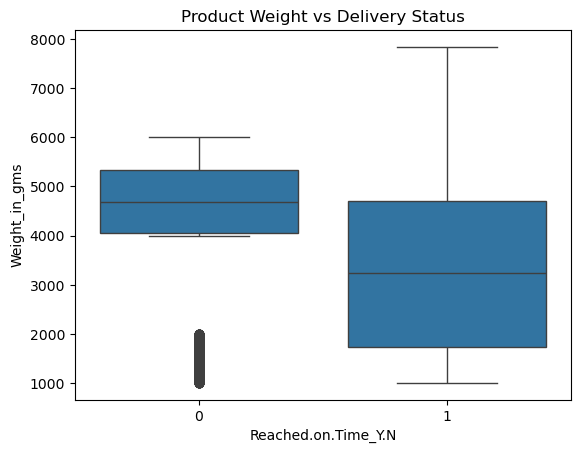

In [85]:
sns.boxplot(
    x='Reached.on.Time_Y.N',
    y='Weight_in_gms',
    data=df
)
plt.title("Product Weight vs Delivery Status")
plt.show()
# sns.boxplot(
#     x='Reached.on.Time_Y.N',
#     y='Discount_offered',
#     data=df
# )
# plt.title("Discount Offered vs Delivery Status")
# plt.show()

Imagine two types of packages:
Heavy packages
Difficult to transport
Requires more handling time
Likely to be delayed more
Light packages
Easy to transport quickly
Faster transport
Likely to arrive on time
1-3 This company operates a shipping operation where:
Most goods are shipped by sea (slower but cheaper)
Warehouse F handles the largest volume
Heavier products are the main cause of delays

In [2]:
# sns.scatterplot(
#     x='Discount_offered',
#     y='Weight_in_gms',
#     hue='Reached.on.Time_Y.N',
#     data=df
# )

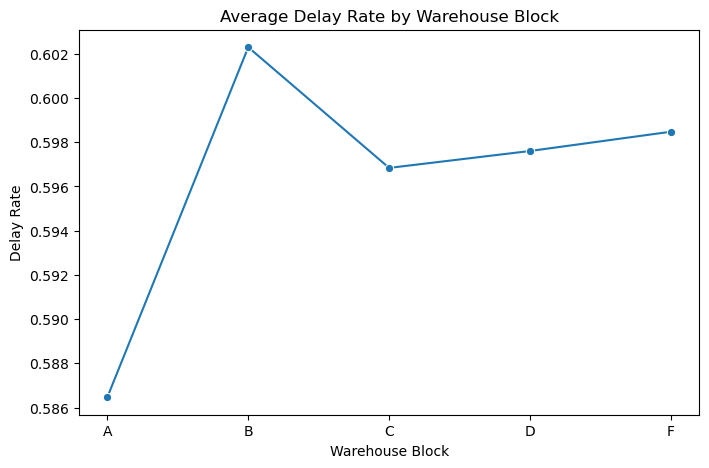

In [87]:
warehouse_delay = (
    df.groupby('Warehouse_block')['Reached.on.Time_Y.N']
    .mean()
    .reset_index()
)
plt.figure(figsize=(8,5))
sns.lineplot(
    data=warehouse_delay,
    x='Warehouse_block',
    y='Reached.on.Time_Y.N',
    marker='o'
)
plt.title('Average Delay Rate by Warehouse Block')
plt.xlabel('Warehouse Block')
plt.ylabel('Delay Rate')
plt.show()

Storytelling
Imagine a logistics manager trying to understand why some orders arrive late. Looking at the delay rates across warehouses, the first thing that stands out is Warehouse B. It experiences slightly more delays than the others, making it a potential area of concern.

Warehouse A performs the best, showing the lowest delay rate. The remaining warehouses fall somewhere in between, with performance levels that are quite similar.

This tells us that while Warehouse B may need special attention, delays are not isolated to one location. The issue likely involves broader operational factors affecting the entire delivery network.
Possible Actions for the Future
Monitor Operational Efficiency
Track warehouse processing times and shipment preparation times to detect bottlenecks early.

In [3]:
# pair_df = df[[
#     'Discount_offered',
#     'Weight_in_gms',
#     'Cost_of_the_Product',
#     'Prior_purchases',
#     'Reached.on.Time_Y.N'
# ]]
# sns.pairplot(
#     pair_df,
#     hue='Reached.on.Time_Y.N',
#     diag_kind='hist'
# )
# plt.show()

In [4]:
# plt.figure(figsize=(10,6))
# sns.heatmap(
#     df.corr(numeric_only=True),
#     annot=True,
#     cmap='Blues'
# )
# plt.title("Correlation Heatmap")
# plt.show()